In [80]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional
import sys
import os
import tqdm

# This (hopefully) sets the root directory for anyone using the repo
cwd = os.getcwd()  # poison-perf/poisoning/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, RGD_audit, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_non_convex_1d, setup_2d_non_linear_experiment, setup_non_convex_nd
# from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator, classification_sampling_estimator, gaussian_sampling_estimator
from poisoning.black_box import black_box_naive, black_box_orthogonal, black_box_cluster
from utils.plotting import plot_results_1d, plot_results_2d

# Nonlinear Mean

In [81]:
a0 = 1.0
a1 = 1.0

proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat, info = setup_1d_non_linear_experiment(a0=a0, a1=a1, perfGD=True)

### Visualize Effect of Black Box Mean Shift on Samples


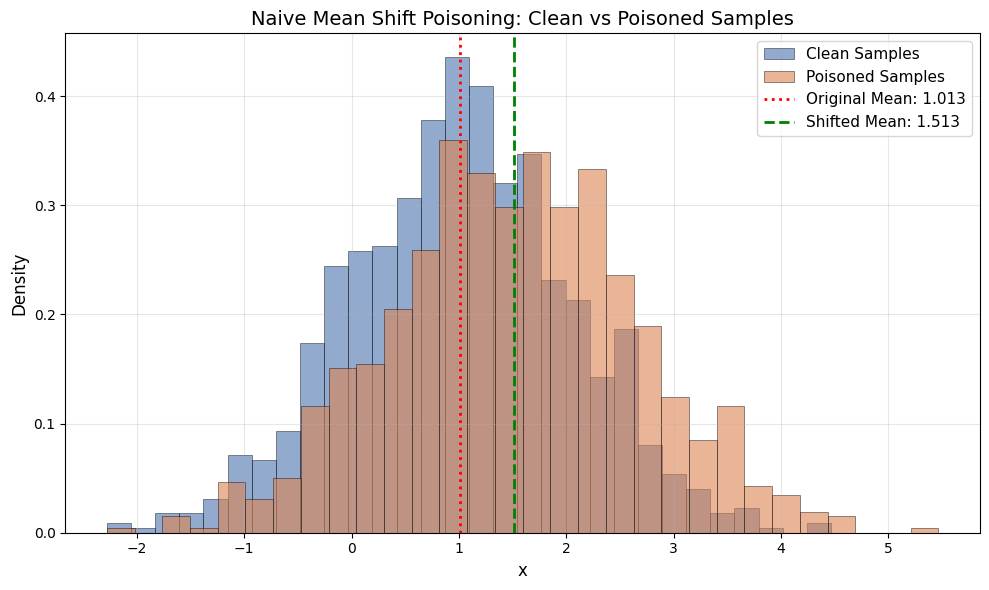

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Naive Mean Shift Poisoning: Clean vs Poisoned Samples'}, xlabel='x', ylabel='Density'>)

In [82]:
# Visualize poisoning effect on samples (1D Nonlinear Mean Shift)
from utils.plotting import plot_clean_vs_poisoned_samples_1d

# Set up parameters
black_box_poison_function = black_box_naive  # Changed to naive mean shift
epsilon = 0.5
delta = 1.0
n = 1000

# Get initial clean samples (no RGD, just one sample from D_theta)
z_clean = D_theta(theta_0, n)

# Apply poisoning once
z_poisoned = black_box_poison_function(
    z_clean, 
    theta_0, 
    eta=0.05,  # Not used by naive, but required
    epsilon=epsilon,
    delta=delta
)

# Visualize the comparison
plot_clean_vs_poisoned_samples_1d(z_clean, z_poisoned, title_prefix="Naive Mean Shift Poisoning: ")

## RGD + Naive Mean Shift

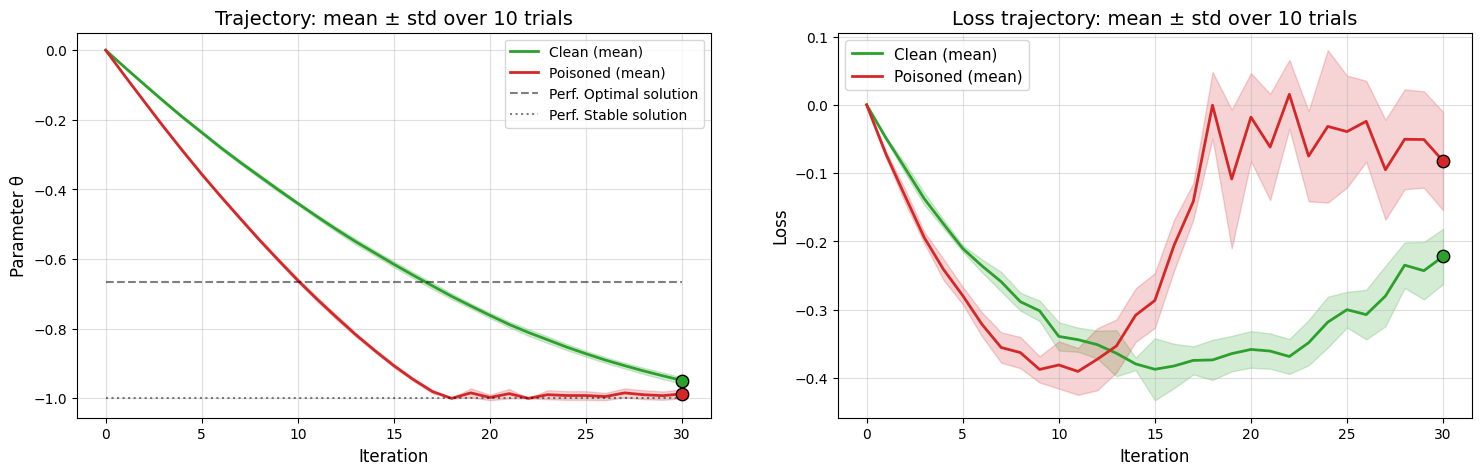

In [83]:
black_box_poison_function = black_box_naive

n_trials = 10

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                proj_theta=proj_theta,
                normalize_grad=False,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                proj_theta=proj_theta,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

ax1.hlines(info['theta_optimal'], xmin=0, xmax=30, color='black', linestyle='--', label='Perf. Optimal solution', alpha=0.5)
ax1.hlines(info['theta_stable'], xmin=0, xmax=30, color='black', linestyle=':', label='Perf. Stable solution', alpha=0.5)
ax1.legend()

plt.show()

## PerfGD + Naive Mean Shift

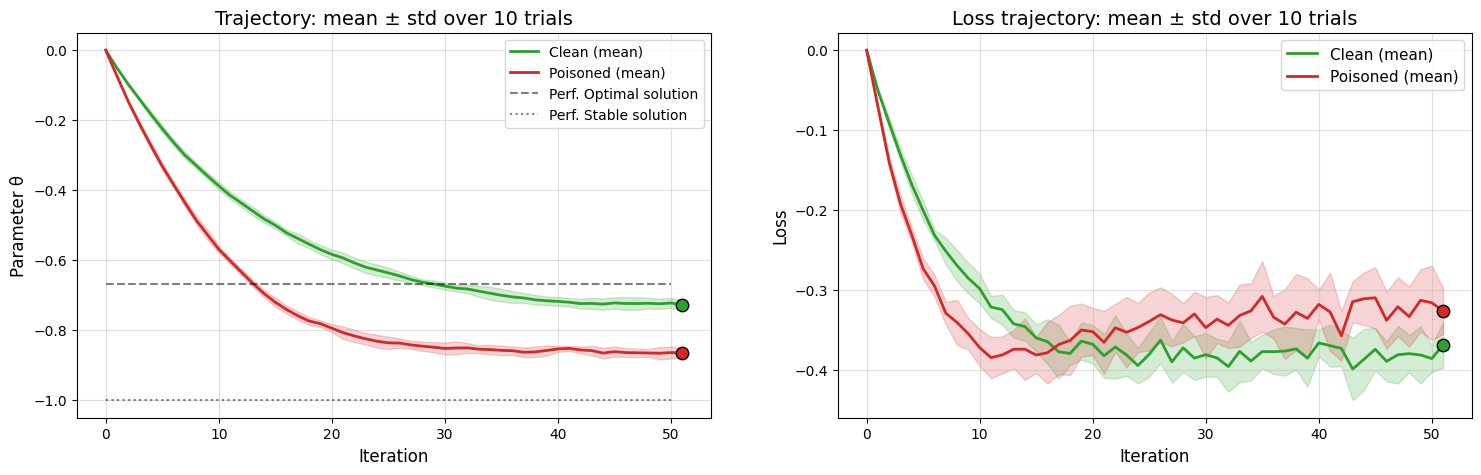

In [84]:
black_box_poison_function = black_box_naive

n_trials = 10

n = 500
eta = 0.05
max_iter = 50

epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True  
    )

    _, all_theta_poisoned, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

ax1.hlines(info['theta_optimal'], xmin=0, xmax=50, color='black', linestyle='--', label='Perf. Optimal solution', alpha=0.5)
ax1.hlines(info['theta_stable'], xmin=0, xmax=50, color='black', linestyle=':', label='Perf. Stable solution', alpha=0.5)
ax1.legend()

plt.show()

# Binary Classification

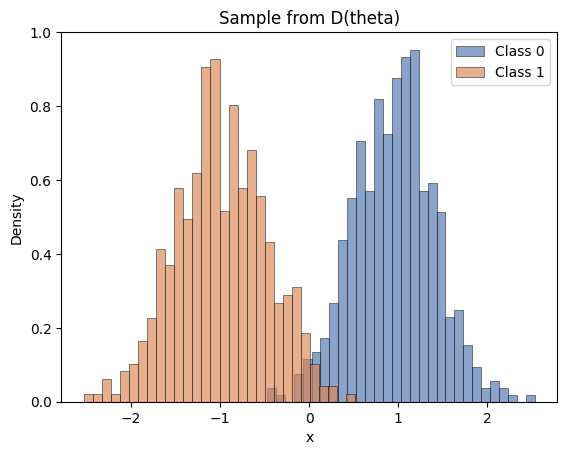

In [85]:
mu_f, mu_0, sigma_0, sigma_1, D_theta, loss, theta_0, grad2_est, f_hat = setup_binary_classification(perfGD=True)
proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)

x, y = D_theta(n=1000, theta=theta_0)

# prettier colors and styled histograms
colors = ['#4C72B0', '#DD8452']  # muted blue and warm orange

x0 = x[(y == 0).bool()].numpy()
x1 = x[(y == 1).bool()].numpy()

plt.hist(x0, bins=30, density=True, alpha=0.65, color=colors[0],
         edgecolor='k', linewidth=0.5, label='Class 0')
plt.hist(x1, bins=30, density=True, alpha=0.65, color=colors[1],
         edgecolor='k', linewidth=0.5, label='Class 1')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Sample from D(theta)')
plt.legend(frameon=True)
plt.show()

### Visualize Effect of Black Box Poisoning on Clusters

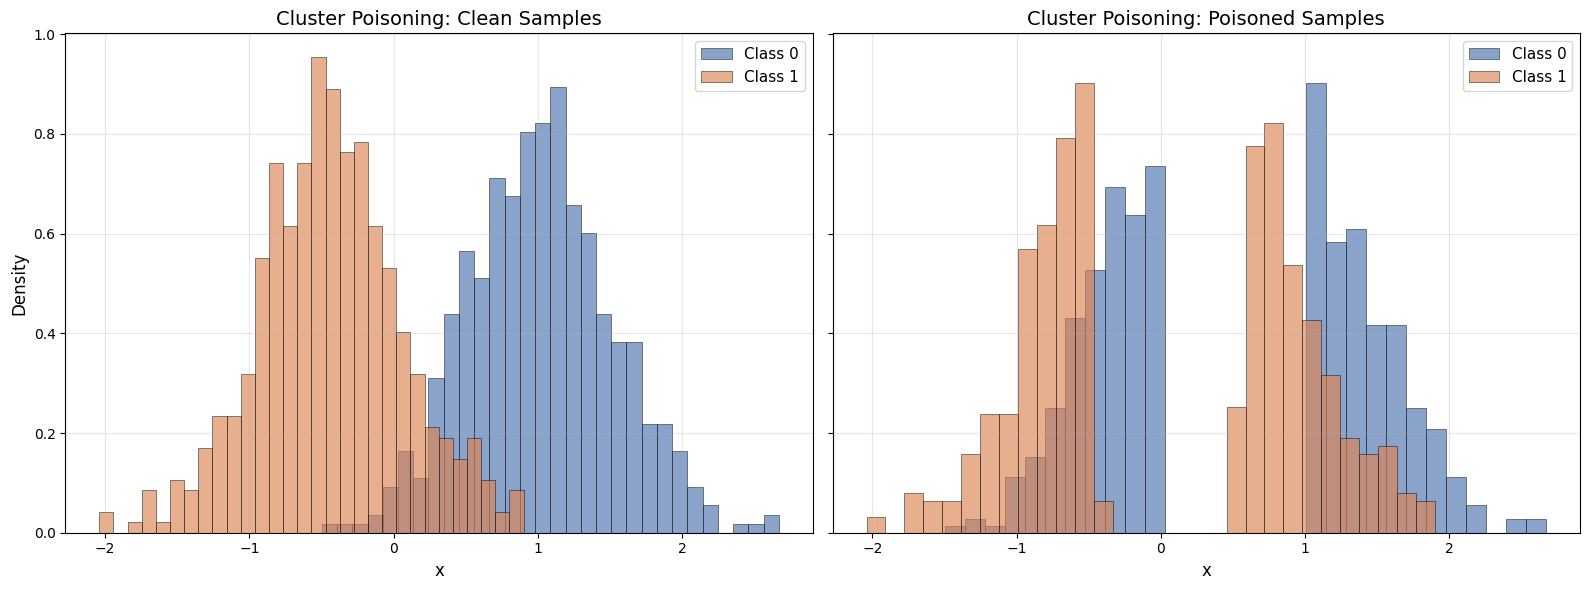

(<Figure size 1600x600 with 2 Axes>,
 (<Axes: title={'center': 'Cluster Poisoning: Clean Samples'}, xlabel='x', ylabel='Density'>,
  <Axes: title={'center': 'Cluster Poisoning: Poisoned Samples'}, xlabel='x'>))

In [86]:
# Visualize poisoning effect on samples
from utils.plotting import plot_clean_vs_poisoned_samples

# Set up parameters
black_box_poison_function = black_box_cluster
epsilon = 0.5
delta = 1.0
n = 1000
eta = 0.05
max_iter = 30
proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)

# Run RGD with return_samples=True to get clean and poisoned samples
_, _, z_clean, z_poisoned = RGD(
    D_theta=D_theta,
    loss=loss,
    theta_0=theta_0.clone(),
    n=n,
    eta=eta,
    max_iter=max_iter,
    proj_theta=proj_theta,
    poison_function=black_box_poison_function,
    normalize_grad=False,
    return_samples=True,  # This returns z_clean and z_poisoned
    epsilon=epsilon,
    delta=delta
)

# Visualize the comparison
plot_clean_vs_poisoned_samples(z_clean, z_poisoned, title_prefix="Cluster Poisoning: ")

## RGD + Cluster Shift

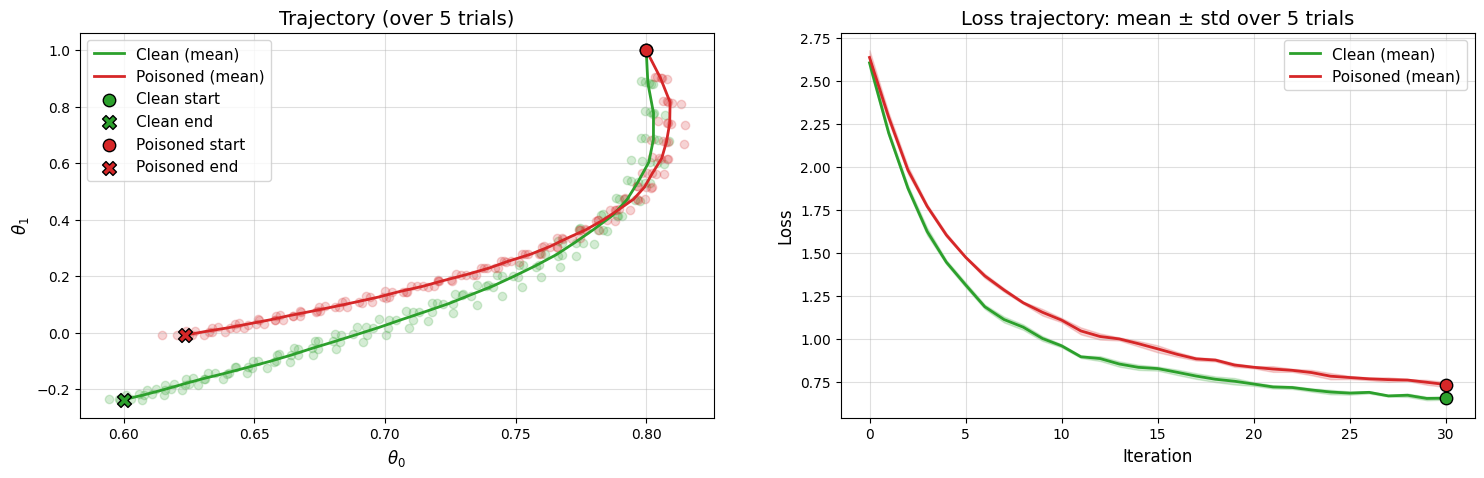

In [87]:
black_box_poison_function = black_box_cluster

n_trials = 5

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1

theta_0 = torch.tensor([0.8,1.0])

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

## PerfGD + Cluster Shift

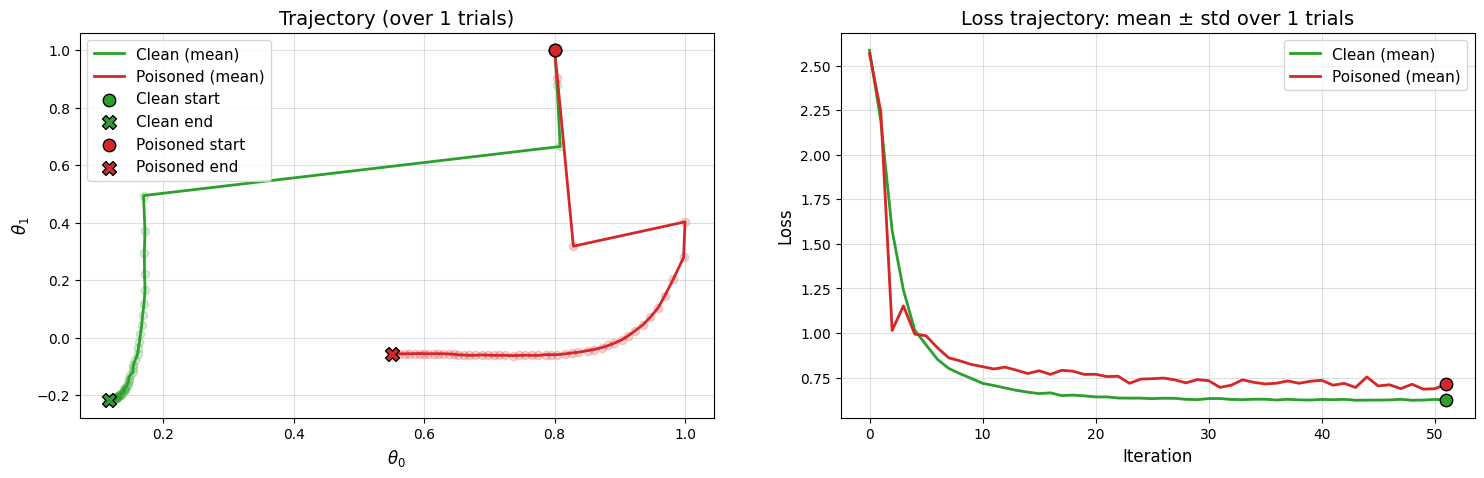

In [88]:
black_box_poison_function = black_box_cluster

n_trials = 1

n = 500
eta = 0.05
max_iter = 50

epsilon = 0.5
delta = 1

theta_0 = torch.tensor([0.8, 1.0])

def run_trial():
    _, all_theta_clean, all_losses_clean = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

# 2D Example

In [89]:
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat, info = setup_2d_non_linear_experiment(perfGD=True)
proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)

## RGD + Orthogonal Mean Shift

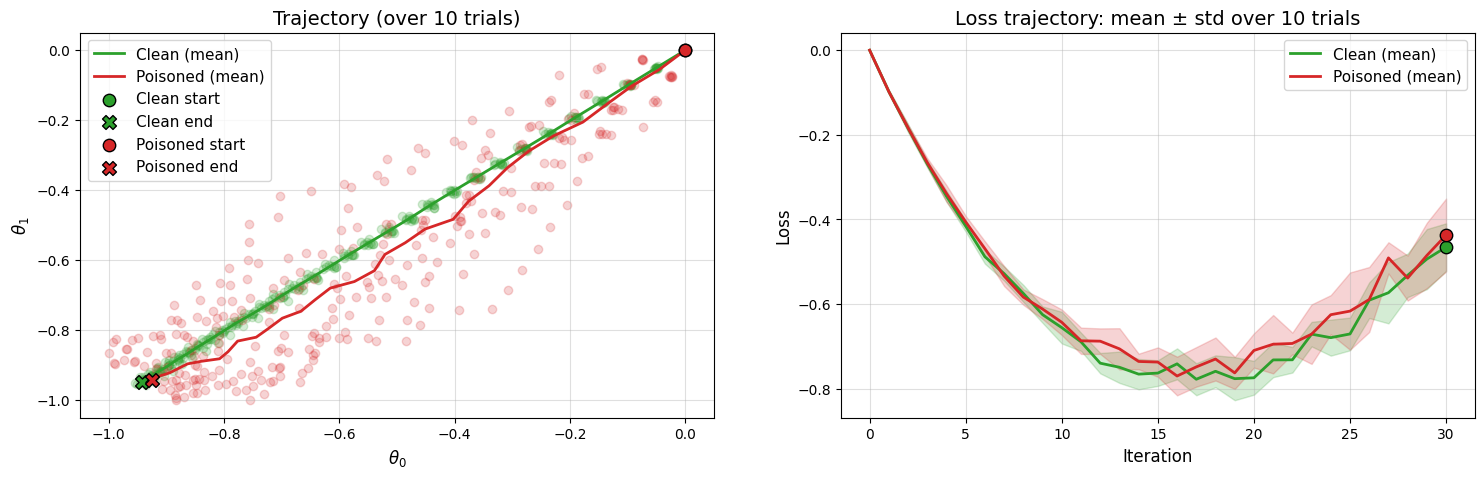

In [90]:
black_box_poison_function = black_box_orthogonal

n_trials = 10

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()

# 10-Dimensional Non-Convex

In [91]:
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_non_convex_nd(perfGD=True)

# Hyperparameters
n = 500
eta = 0.04
max_iter = 150
normalize_grad = True
delta_vals = np.linspace(0.0, 2, 49)
epsilon = 0.5
poison_step_size = 0.1
norm = 'linf'
n_trials_per_delta = 1

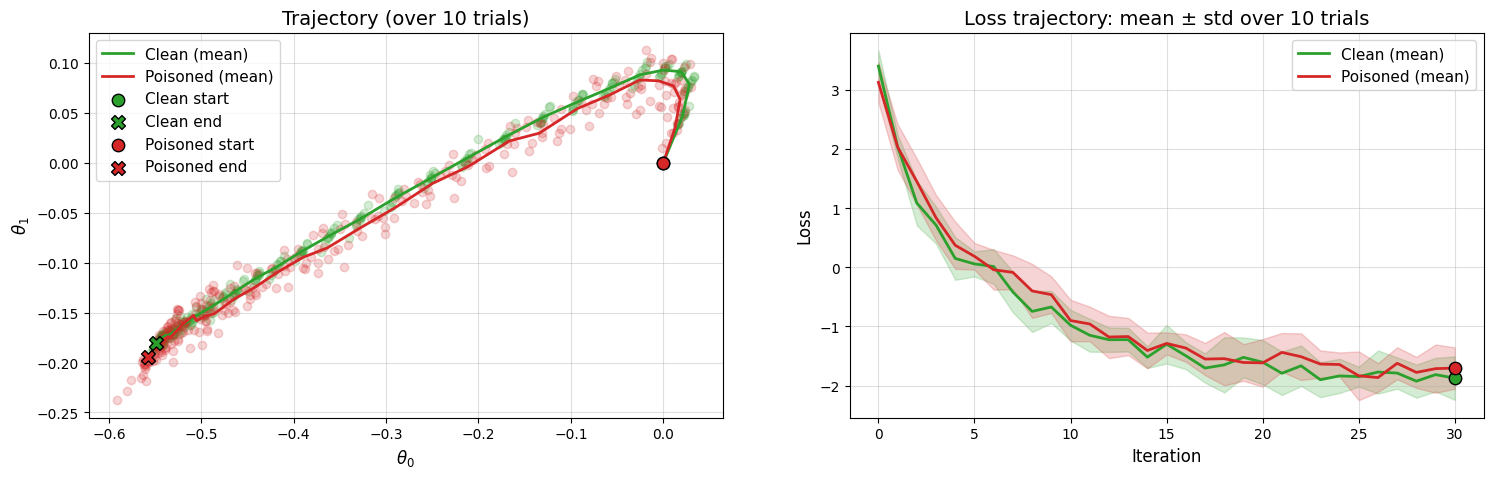

In [92]:
black_box_poison_function = black_box_orthogonal

n_trials = 10

n = 500
eta = 0.05
max_iter = 30

epsilon = 0.5
delta = 1.0

def run_trial():
    _, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True
    )

    _, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                normalize_grad=False,
                return_losses=True,
                poison_function=black_box_poison_function,
                epsilon=epsilon,
                delta=delta,
            )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_2d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()